# Data Importation

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate


data = pd.read_csv(r"D:\Para Verano\GitHub\learning-ai-summer-2026\Fase2-ML\Titanic - Machine Learning from Disaster\data\train.csv")
data = data.rename(columns = {
    "PassengerId": "PassengerId",
    "Survived": "Survived",
    "Pclass": "ClassStatus",
    "Name": "Name",
    "Sex": "Sex",
    "Age": "Age",
    "SibSp": "SiblingRelation",
    "Parch": "FamilyRelation",
    "Ticket": "TicketNumber",
    "Fare": "PassangerFare",
    "Cabin": "CabinNumber",
    "Embarked": "PortEmbarked"
})

change_classes = {
    1: "Upper",
    2: "Middle",
    3: "Lower",
}

change_embarked = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
}

change_survived = {
    1: "Yes",
    0: "No"
}

data["ClassStatus"] = data["ClassStatus"].map(change_classes)
data["PortEmbarked"] = data["PortEmbarked"].map(change_embarked)
data["Survived"] = data["Survived"].map(change_survived)

print(tabulate(data, headers = ["PassengerId", "Survived", "ClassStatus", "Name", "Sex", "Age", "SiblingRelation", "FamilyRelation", 
                                "TicketNumber", "PassangerFare", "CabinNumber", "PortEmbarked"]))

       PassengerId  Survived    ClassStatus    Name                                                                                Sex        Age    SiblingRelation    FamilyRelation  TicketNumber          PassangerFare  CabinNumber      PortEmbarked
---  -------------  ----------  -------------  ----------------------------------------------------------------------------------  ------  ------  -----------------  ----------------  ------------------  ---------------  ---------------  --------------
  0              1  No          Lower          Braund, Mr. Owen Harris                                                             male     22                     1                 0  A/5 21171                    7.25    nan              Southampton
  1              2  Yes         Upper          Cumings, Mrs. John Bradley (Florence Briggs Thayer)                                 female   38                     1                 0  PC 17599                    71.2833  C85              Cherbour

In [25]:
data.dtypes

PassengerId          int64
Survived               str
ClassStatus            str
Name                   str
Sex                    str
Age                float64
SiblingRelation      int64
FamilyRelation       int64
TicketNumber           str
PassangerFare      float64
CabinNumber            str
PortEmbarked           str
dtype: object

# EDA

In [26]:
data.describe()

,PassengerId,Age,SiblingRelation,FamilyRelation,PassangerFare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


## 1. Checking nulls

In [27]:
data.isna().sum()

PassengerId          0
Survived             0
ClassStatus          0
Name                 0
Sex                  0
Age                177
SiblingRelation      0
FamilyRelation       0
TicketNumber         0
PassangerFare        0
CabinNumber        687
PortEmbarked         2
dtype: int64

There are some NaNs (or Nulls values) that we should treat before any analysis/ML model.

## 2. Analayzing Distributions

<Axes: >

<Figure size 640x480 with 0 Axes>

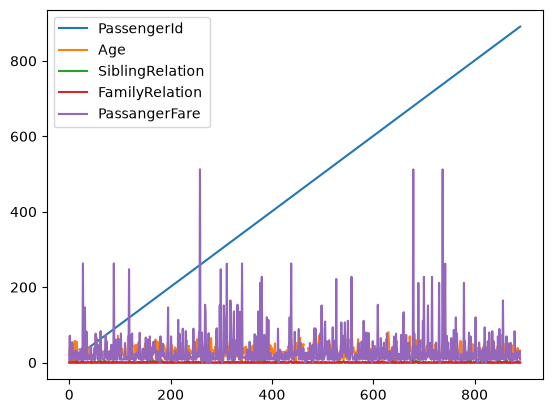

In [28]:
plt.figure()
data.plot()

ClassStatus      Lower  Middle  Upper
Sex    Survived                      
female No           72       6      3
       Yes          72      70     91
male   No          300      91     77
       Yes          47      17     45
Survived             No  Yes
Sex    ClassStatus          
female Lower         72   72
       Middle         6   70
       Upper          3   91
male   Lower        300   47
       Middle        91   17
       Upper         77   45


<Axes: xlabel='Sex,ClassStatus'>

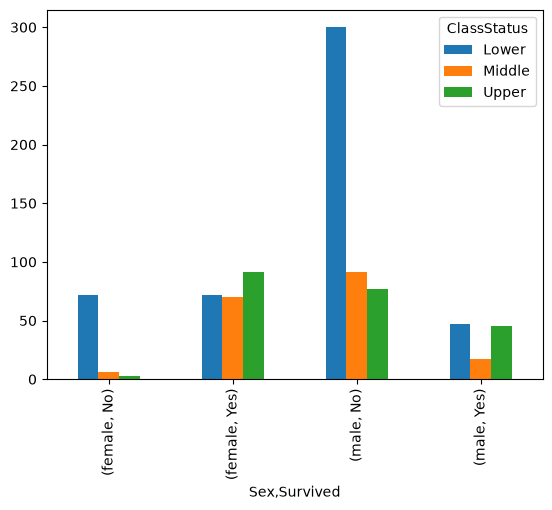

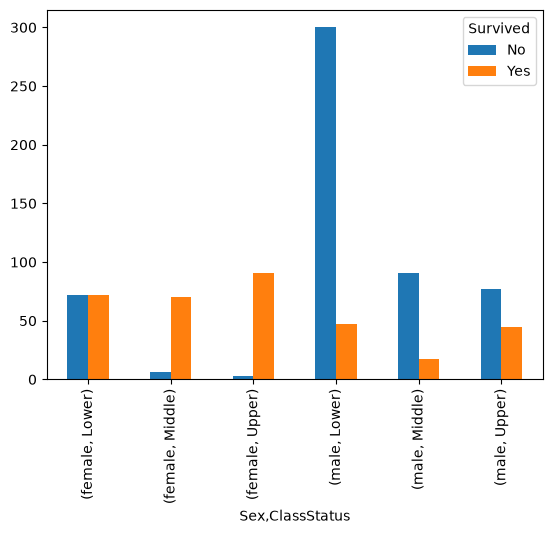

In [29]:
counting1 = data.groupby(["Sex", "Survived", "ClassStatus"]).size().unstack()
print(counting1)
counting1.plot(kind = "bar")

counting2 = data.groupby(["Sex", "Survived", "ClassStatus"]).size().unstack(1)
print(counting2)
counting2.plot(kind = "bar")

In [ ]:
pair = pd.crosstab(data["ClassStatus"], data["Sex"])

: 